#### Carnegie Mellon University - Tepper School of Business
#### 46-886 - Machine Learning Fundamentals
#### 22/23 - Mini 4 - Section M4 - Farahat
---

## Deliverable 2 
**Due Wednesday, March 22th at 2:59 a.m. Pittsburgh time**

**This is an individual assignment.**

*This deliverable consists of **one** problem of several parts. Each part requires you to code in **Python** and answer one or more questions. Save a copy of this notebook and provide your solution by inserting code or Markdown text cells as appropriate.*

*You will need to submit two files through Canvas: 1) a completed Jupyter notebook (extension .ipynb) with your code and answers to each question (this file); and 2) an html rendering of your completed Jupyter notebook.*

### Problem 1 - Preventing Hospital Readmissions (100 points)

A key performance metric for hospitals is the *30-day unplanned readmission rate* -- the proportion of patients discharged from the hospital who had an unplanned readmission within 30 days. Programs like the Hospital Readmissions Reduction Program (HRRP) apply penalties (up to a 3% reduction in payments) to underperforming U.S. hospitals -- resulting in withheld payments in excess of $500 million in 2018.

Hospitals can employ some low-cost strategies to reduce unplanned readmissions, such as confirming patient follow-up plans prior to discharge and asking patients to verbally repeat their treatment directions. However, other approaches are more involved and costly. One example is to arrange “telehealth” interventions, in which health care providers contact patients routinely after discharge. Given the cost of these interventions, they are only appropriate for patients at elevated risk of readmission.

Suppose you are working for a mid-sized hospital in the northeast United States, and are tasked to assess the impact of telehealth interventions on diabetic patients -- with the ultimate goal of reducing the 30-day readmission rate. The intervention will cost approximately $1,200 per patient. Clearly, it must be limited in scope, and a key component of your strategy will be targeting the “right" patients.

Unfortunately, your hospital does not document 30-day readmissions, as this requires significant follow-up with discharged patients. You will thus use a publicly-available dataset to study readmission risk. The dataset includes over 100,000 hospital discharges of over 70,000 diabetic patients from 130 hospitals across the United States during the period 1999-2008 <a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1). All patients were hospital inpatients for 1-14 days, and received both lab tests and medications while in the hospital. The 130 hospitals represented in the dataset vary in size and location: 58 are in the northeast United States and 78 are mid-sized (100-499 beds). 

The dataset is randomly split into train <readmission_train.csv> and test <readmission_test.csv> sets. The data consist of the following variables:

-  **readmission**: 1 if the patient had an unplanned readmission within 30 days, 0 otherwise.
-  **Patient characteristics**: **age** captures demographic information.
-  **Recent medical system use**: The variables **numberEmergency**, and **numberInpatient** capture the number of times the patient used the medical system in the last year.
-  **Diabetic treatments**: A number of variables capture the patient's diabetic treatments: **insulin**,  **metformin**
-  **Admission information**: **numberDiagnoses** captures the number of diagnoses the patient had recorded for their admission. There are also a number of variables that indicate whether a patient was diagnosed with various conditions when admitted: **diagAnemia**, **diagAsthma**, **diagAthlerosclerosis**, **diagCellulitis**, **diagCKD**, **diagDyspnea**, **diagHeartFailure**, **diagHypertension**, **diagHypertensiveCKD**, **diagPneumonia**, and **diagSkinUlcer**.
-  **Treatment information**: **timeInHospital** is the number of days the patient was in the hospital, and **numNonLabProcedures**, and **numMedications** capture the amount of care the patient received in the hospital.

Based on conversations with the hospital's management, you estimate the cost of a 30-day unplanned readmission at $35,000. From published information at a similar institution, you estimate that telehealth interventions will reduce the incidence of 30-day unplanned readmissions in the treated population by 25%.

<a name="cite_note-1"></a> [1](#cite_ref-1) Beata Strack, Jonathan P. DeShazo, Chris Gennings, et al., “Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records," BioMed Research International, vol. 2014, 2014.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_graphviz
from graphviz import Source
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [3]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [4]:
pd.options.display.max_columns = None

In [5]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

In [6]:
df = pd.read_csv("readmission_train.csv")


#### Part (a)

Fit a Classification Tree model with maximum depth equal to 4 (use default values for the other parameters). Provide an image of your tree.

In [7]:
df.dropna(axis = 0, how = 'any', inplace = True) 

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
df

,readmission,numberEmergency,numberInpatient,insulin,metformin,numberDiagnoses,diagAnemia,diagAsthma,diagAthlerosclerosis,diagCellulitis,diagCKD,diagDyspnea,diagHeartFailure,diagHypertension,diagHypertensiveCKD,diagPneumonia,diagSkinUlcer,timeInHospital,numNonLabProcedures,numMedications,age_[10-20),age_[20-30),age_[30-40),age_[40-50),age_[50-60),age_[60-70),age_[70-80),age_[80-90),age_[90-100)
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,6,0,0,0,0,0,0,0,0,0,0,0,2,5,13,0,1,0,0,0,0,0,0,0
2,0,0,0,1,0,5,0,0,0,0,0,0,0,0,0,0,0,1,0,8,0,0,0,1,0,0,0,0,0
3,0,0,0,1,0,9,0,0,1,0,0,0,0,0,0,0,0,3,6,16,0,0,0,0,1,0,0,0,0
4,0,0,0,1,1,7,0,0,1,0,0,0,0,0,0,0,0,4,1,21,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71231,0,0,0,1,0,7,0,0,0,0,0,0,0,0,0,0,0,1,0,15,0,0,0,0,0,0,0,1,0
71232,0,1,2,1,0,9,0,0,0,0,0,0,0,0,0,0,0,6,1,25,0,0,0,0,0,1,0,0,0
71233,0,0,0,1,1,9,0,0,0,0,0,0,0,0,0,0,0,3,0,16,0,0,0,0,0,0,1,0,0
71234,0,0,1,1,0,9,0,0,0,0,0,0,0,0,0,0,0,5,3,18,0,0,0,0,0,0,0,1,0


In [10]:
y_train = df["readmission"]

In [11]:
X_train = df.drop("readmission",axis=1)

In [12]:
tree_mod = DecisionTreeClassifier(max_depth=4, random_state=886)
tree_mod.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=886)

In [13]:
print(tree_mod.tree_.threshold) 

[ 1.5  0.5  4.5  8.5 -2.  -2.   0.5 -2.  -2.   0.5 16.5 -2.  -2.   2.5
 -2.  -2.   4.5  2.5  0.5 -2.  -2.   0.5 -2.  -2.   7.5  1.5 -2.  -2.
 10.5 -2.  -2. ]


In [14]:
export_graphviz(
        tree_mod,
        out_file="readmission.dot",
        feature_names=X_train.columns,
        impurity=False,
        rounded=True,
        filled=True
    )

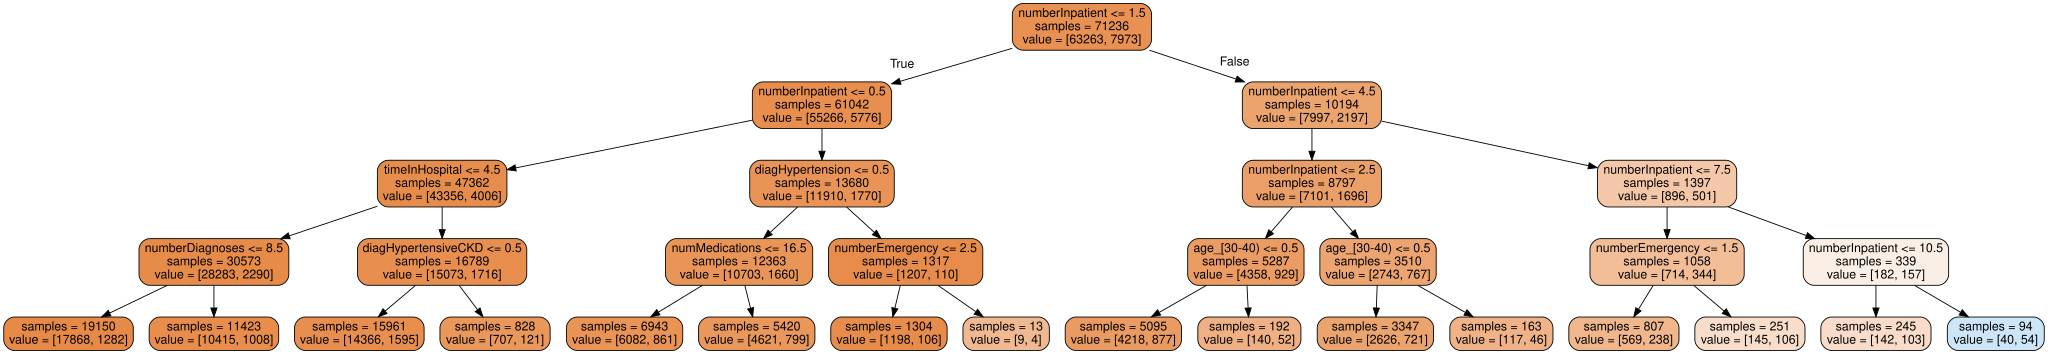

In [15]:
Source.from_file("readmission.dot")

#### Part (b)

Given the cost of $1,200 per intervention, what classification threshold would you use on the probability of re-admission? That is, for what values of the probability would you recommend intervention?

In [16]:
mythreshold = 0.13714286

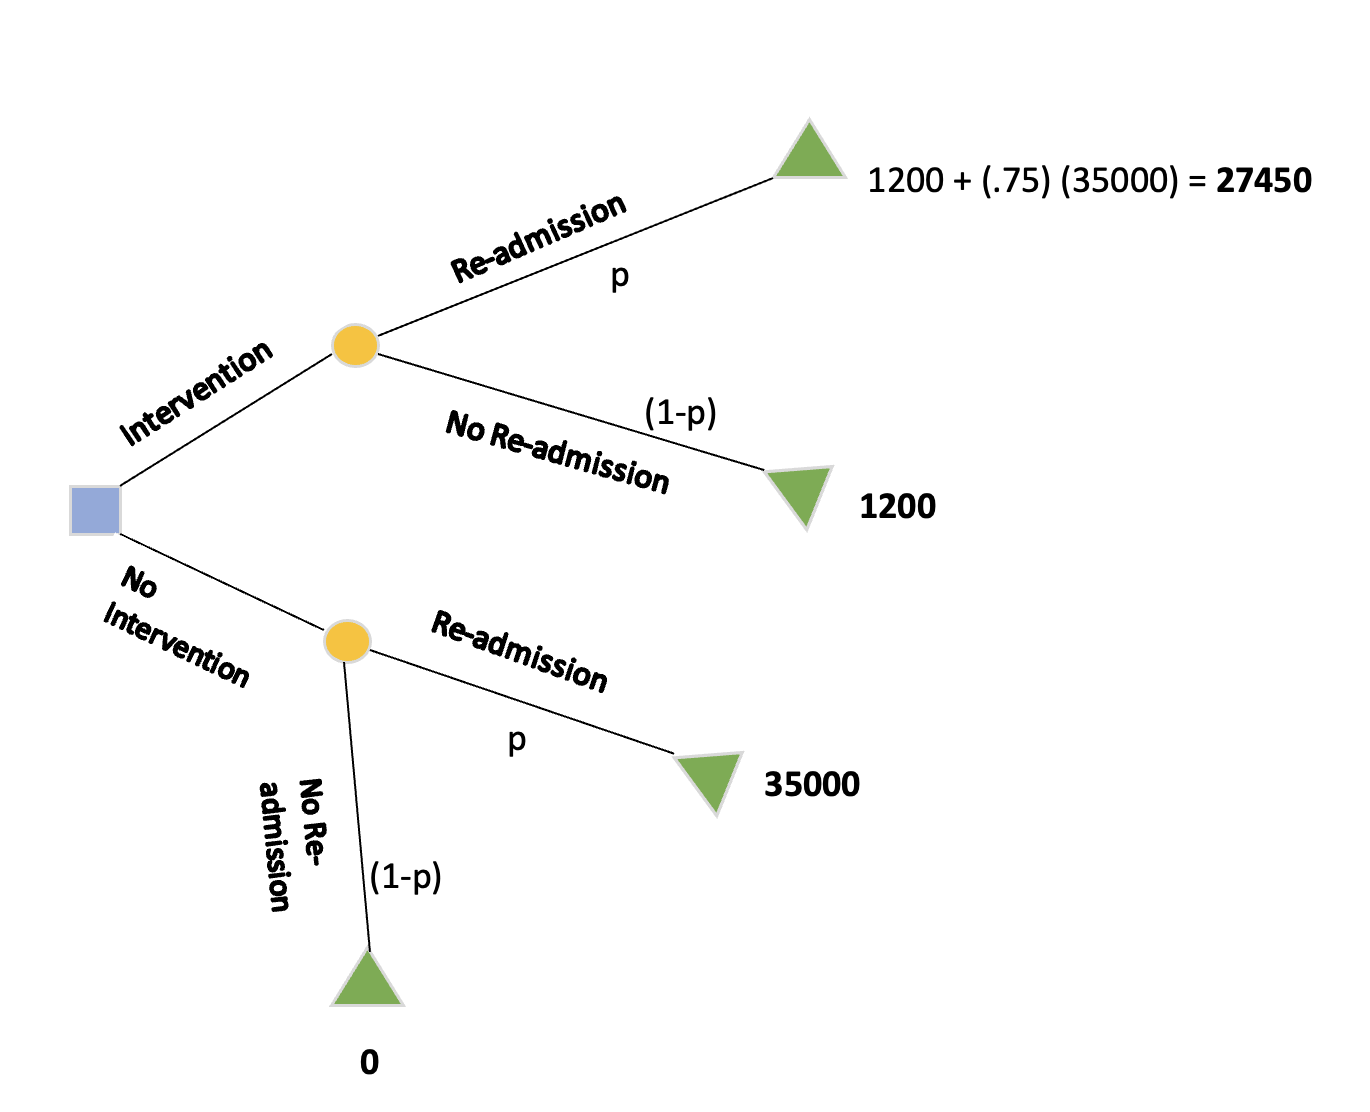

We want to compare the cost between the telehealth interventions vs no interventions at all. We'd go with the interventions if the cost is less when compared. The Objective is to determine the threshold that puts high number of patients in the False positives category when compared to False Negatives. This is because the False positives are cost effective than False Negatives.

So the equation becomes:

#### 27450 p + (1-p)* 1200 < 35000 p + (1-p)* 0
#### Solving for p, we get p > 1200/8750 i.e. p > 0.13714286. 

For probabilities greater than 0.13714286, we will do the interventions.

#### Part (c)

Provide the confusion matrix (on the test set) associated with the Classification Tree model you developed in Part (a) and the classification threshold you identified in part (b). Use the convention that readmission is the "positive" outcome. Also, construct your confusion matrix so that the rows correspond to actual outcomes and columns correspond to predicted outcomes.

In [17]:
df_test= pd.read_csv("readmission_test.csv")

In [18]:
df_test.dropna(axis = 0, how = 'any', inplace = True) 

In [19]:
df_test = pd.get_dummies(df_test, drop_first=True)

In [20]:
y_test = df_test["readmission"]

In [21]:
X_test = df_test.drop("readmission",axis=1)

In [22]:
treemod_pred_prob = tree_mod.predict_proba(X_test)

In [23]:
treemod_pred_prob

array([[0.91175698, 0.08824302],
       [0.93305483, 0.06694517],
       [0.90006892, 0.09993108],
       ...,
       [0.87599021, 0.12400979],
       [0.91175698, 0.08824302],
       [0.90006892, 0.09993108]])

In [24]:
treemod_decisions = (treemod_pred_prob[:,1] >= mythreshold).astype(int)
treemod_decisions

array([0, 0, 0, ..., 0, 0, 0])

In [25]:
treemod_cm = confusion_matrix(y_test, treemod_decisions)
treemod_cm

array([[21283,  5863],
       [ 2105,  1279]])

#### Part (d)

What is the accuracy, sensitivity, and specficity of the model? 

In [26]:
accuracy = accuracy_score(y_test, treemod_decisions)
accuracy

0.7390108090402883

In [27]:
sensitivity  = treemod_cm[1,1]/ (treemod_cm[1,1] + treemod_cm[1,0]) 
sensitivity

0.37795508274231676

In [28]:
specificity  = treemod_cm[0,0]/ (treemod_cm[0,0] + treemod_cm[0,1]) 
specificity

0.7840197450821483

#### Part (e)

What is the economic cost (per patient) if you follow the recommendations of the model? 

In [30]:
econ_cost = (1200 * treemod_cm[0,1] + 27450 * treemod_cm[1,1] ) / sum(sum(treemod_cm))
econ_cost

1380.4176220111367

#### The economic cost to the hospital per patient is $1380.42

----